In [1]:
# 7.1
import numpy as np
from numpy import linalg as la

np.set_printoptions(suppress=True)

A = np.array([1, 2, 3, 0, -4, 1, 0, 3, -1]).reshape(3, 3)
Adet = la.det(A)
print(f'A: {A} has determinant: {Adet}\n')

b = np.array([2, 2, 1])
print(f"Solution: {np.array(['x', 'y', 'z'])} = {la.solve(A, b)}\n")

print(f'Matrix is orthogonal: {np.array_equal(A.T, la.inv(A))}')
print(f'Alternative check with function allclose(): {np.allclose(A.T, la.inv(A))}\n')

eval, evect = la.eig(A)
print(f'Eigenvalues: {eval}')
print(f'Eigenvectors: \n{evect}')

A: [[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]] has determinant: 1.0

Solution: ['x' 'y' 'z'] = [ 38.  -3. -10.]

Matrix is orthogonal: False
Alternative check with function allclose(): False

Eigenvalues: [ 1.         -4.79128785 -0.20871215]
Eigenvectors: 
[[ 1.         -0.05055961  0.94256676]
 [ 0.         -0.78318743 -0.08518794]
 [ 0.          0.6197267  -0.32297201]]


In [2]:
# 7.3
from numpy import cos, sin
import numpy as np
from numpy import linalg as la

def Ez(angle):
    angle = np.radians(angle)
    Ez = np.array([cos(angle), sin(angle), 0, -sin(angle), cos(angle), 0, 0, 0, 1]).reshape(3, 3)
    return Ez

def Ey(beta):
    beta = np.radians(beta)
    Ey = np.array([cos(beta), 0, -sin(beta), 0, 1, 0, sin(beta), 0, cos(beta)]).reshape(3, 3)
    return Ey

# E = Ez(180-123) . Ey(90-27.4) . Ex(192.25)
E = Ez(180-123) @ Ey(90-27.4) @ Ez(192.25)
print(f'E: {E}')

# properties of rotation matrix: R.T=inv(R) and det(R) = 1
print(f'Matrix is orthogonal, so E.T=inv(E): {np.allclose(E.T, la.inv(E))}')
print(f'Determinant should be 1, det = {la.det(E)}')

eval, evect = la.eig(E)
print(f'Eigenvalues: {eval}\n')

ra = np.radians(192.25)
dec = np.radians(27.4)
v = np.array([cos(dec)*cos(ra), cos(dec)*sin(ra), sin(dec)])
print(f'v = {v} and norm = {la.norm(v)})')

rotated_v = E @ v
print(rotated_v)

E: [[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
Matrix is orthogonal, so E.T=inv(E): True
Determinant should be 1, det = 1.0
Eigenvalues: [-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]

v = [-0.86760081 -0.1883746   0.46019978] and norm = 1.0)
[0. 0. 1.]


[[  5.15978035   4.29981696   3.5831808    2.985984     2.48832
    2.0736       1.728        1.44         1.2          1.        ]
 [512.         256.         128.          64.          32.
   16.           8.           4.           2.           1.        ]]
[-0.00021712  0.01099256 -0.23905976  2.91867714]


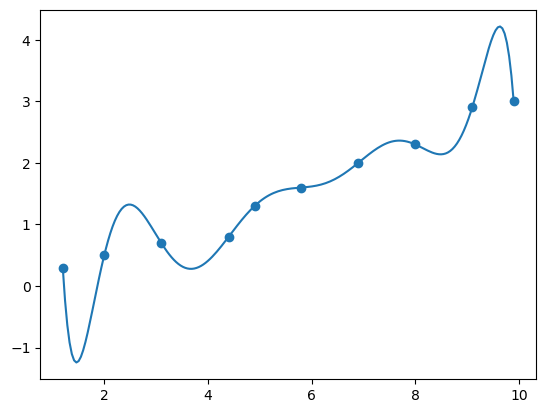

In [26]:
# 7.5
import numpy as np
from numpy.linalg import solve
from matplotlib.pyplot import figure, show

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

N = len(x)
A = np.zeros(shape=(N, N))
for i in range(N):
    for j in range(N):
        A[i, j] = x[i]**(N-1-j)

print(A[:2, :])
sol = solve(A, y)
print(sol[:4])

newx = np.linspace(1.2, 9.9, 200)
newy = np.zeros(shape=newx.shape)

for i in range(N):
    newy += sol[i] * newx**(N - i - 1)

fig = figure()
frame = fig.add_subplot(1, 1, 1)
frame.scatter(x, y)
frame.plot(newx, newy)
show()

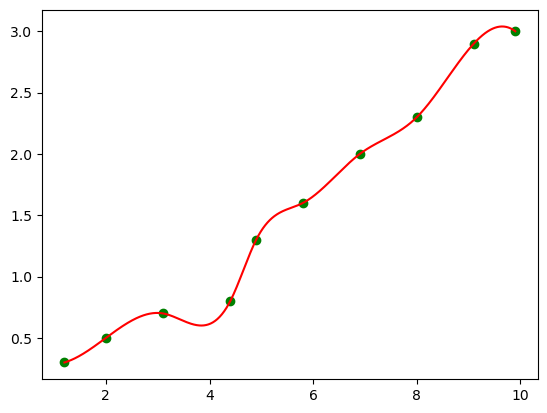

In [8]:
# 7.6
import numpy as np
from matplotlib.pyplot import figure, show
from scipy.interpolate import interp1d

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
f = interp1d(x, y ,kind='cubic')

newx = np.linspace(1.2,9.9,1000)
newy = f(newx)

fig = figure()
frame = fig.add_subplot(1, 1, 1)
frame.plot(x, y, 'go')
frame.plot(newx, newy, 'r')
show()

In [7]:
# 7.7
import numpy as np

I = np.array([[2.0, 4.1], [2.5, 3.8]])

# find interpolated intensity at (0.2, 0.7)
i_f, j_f = 0.2, 0.7
mu = i_f - int(i_f)
lam = j_f - int(j_f)

I_ip = (1-lam)*(1-mu)*I[0,0] + lam*(1-mu)*I[0,1] + mu*(1-lam)*I[1,0] + lam*I[1,1]
print(I_ip)

5.5859999999999985


$$ I_{ip} = (1-\lambda)(1-\mu)I_0 + \lambda(1-\mu)I_1 +\mu(1-\lambda)I_2 +\lambda\mu I_3 $$
With:
$$ \mu = i_f - int(i_f)$$
$$ \lambda = j_f - int(j_f)$$

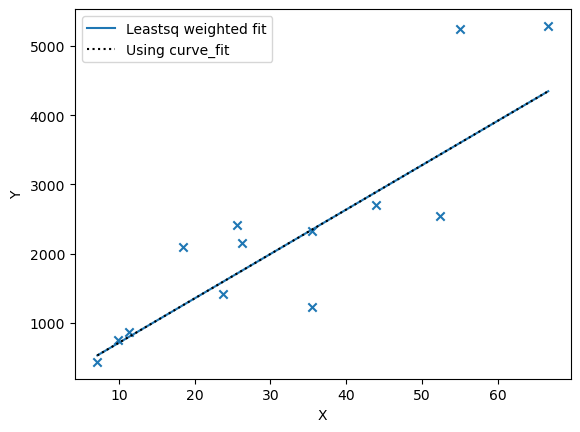

In [78]:
# 7.10
import numpy as np
from scipy.optimize import curve_fit, leastsq
from matplotlib.pyplot import figure, show

data = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]
data = np.asarray(data)
x = data[0::4]
y = data[1::4]
sigx = data[2::4]
sigy = data[3::4]

# The model, usually a function of x
def model(beta, x):
    beta0, beta1 = beta
    return beta0 + beta1*x

# A residuals function
def residuals(beta, x, y, sigy):
    return (y - model(beta,x))/sigy

# Using leastsq
beta_start = [0, 70.0]          # Initial estimates for beta0 and beta1
data = (x, y, sigy)             # You need to pack your data in a tuple
(beta, pcov, infodict, errmsg, ier) = leastsq(residuals, beta_start, args=data, full_output=1)

#Using curve_fit
def func(x, m, b):
    return m*x+b
popt, pcov2 = curve_fit(func, x, y, sigma=sigy)
xfine = np.linspace(np.min(x), np.max(x))

fig = figure()
frame = fig.add_subplot(1, 1, 1)
frame.scatter(x, y, marker='x')
xmin, xmax = np.min(x), np.max(x)
ymin, ymax = model(beta, xmin), model(beta, xmax)
frame.plot([xmin, xmax], [ymin, ymax], label='Leastsq weighted fit')

frame.plot(xfine, func(xfine, *popt), linestyle=':', color='black', label='Using curve_fit')

frame.set_xlabel('X')
frame.set_ylabel('Y')
frame.legend()
show()


In [ ]:
# 7.14